# 2. TF-IDF + Classical ML Baselines


- **Category** (top-8-way): which product/department this complaint belongs to
- **Urgency** (3-way): high / medium / low

TF-IDF + Logistic Regression / Linear SVM. These are the reference point for
judging whether DistilBERT (notebook 3) is actually worth the extra
complexity and training time.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

DATA_DIR = Path.cwd().parent / 'data'
MODEL_DIR = Path.cwd().parent / 'models'
MODEL_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_DIR / 'cfpb_clean.csv')
print(df.shape)
df.head()

(5338, 6)


,text,product,issue,sub_issue,urgency,word_count
0,THE CREDIT BUREAUS NEVER DID A PROPER INVESTI...,Debt collection,Attempts to collect debt not owed,Debt was paid,low,188
1,"When I reviewed my credit report, I discovered...","Credit reporting, credit repair services, or o...",Problem with a credit reporting company's inve...,Their investigation did not fix an error on yo...,medium,131
2,My name is XXXX XXXX this complaint is not mad...,"Credit reporting, credit repair services, or o...",Problem with a credit reporting company's inve...,Their investigation did not fix an error on yo...,medium,108
3,Ive pulled my credit report and the account wi...,"Credit reporting, credit repair services, or o...",Incorrect information on your report,Account status incorrect,medium,121
4,Ive pulled my credit report and the account wi...,"Credit reporting, credit repair services, or o...",Incorrect information on your report,Account status incorrect,medium,121


## 2.1 Train/test split + TF-IDF vectorization

Split is stratified on `product` (the label we care most about getting
right) so both category and urgency splits stay balanced.


In [2]:
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['product'], random_state=42)
print(f'Train: {len(train_df)}, Test: {len(test_df)}')

vectorizer = TfidfVectorizer(max_features=30000, ngram_range=(1,2), sublinear_tf=True, min_df=3)
X_train = vectorizer.fit_transform(train_df['text'])
X_test = vectorizer.transform(test_df['text'])
joblib.dump(vectorizer, MODEL_DIR / 'tfidf_vectorizer.joblib')

print('Vocab size:', len(vectorizer.vocabulary_))


Train: 4270, Test: 1068
Vocab size: 30000


## 2.2 Category classification (top-8-way)

In [3]:
def train_eval(X_train, X_test, y_train, y_test, name):
    results, models = {}, {}
    candidates = {
        'logreg': LogisticRegression(max_iter=2000, class_weight='balanced'),
        'svm': LinearSVC(class_weight='balanced'),
    }
    for model_name, clf in candidates.items():
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        results[f'{name}_{model_name}'] = {
            'accuracy': accuracy_score(y_test, preds),
            'macro_f1': f1_score(y_test, preds, average='macro'),
        }
        models[model_name] = clf
    return results, models

category_results, category_models = train_eval(X_train, X_test, train_df['product'], test_df['product'], 'category')
pd.DataFrame(category_results).T


,accuracy,macro_f1
category_logreg,0.853933,0.653202
category_svm,0.878277,0.656563


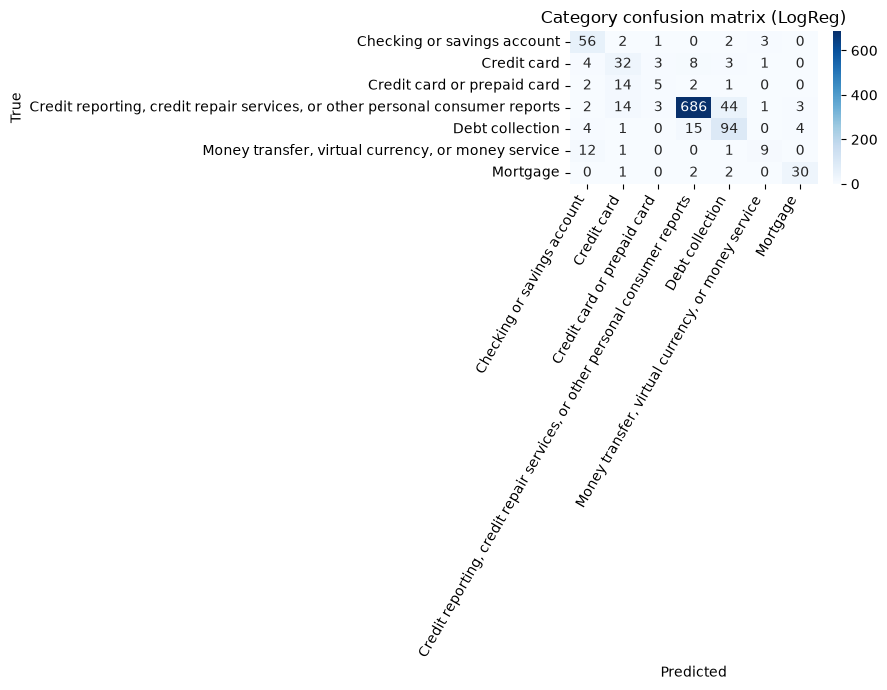

['C:\\Users\\narul\\Documents\\cfpb_triage_final\\models\\tfidf_category_logreg.joblib']

In [4]:
preds = category_models['logreg'].predict(X_test)
labels = sorted(test_df['product'].unique())

cm = confusion_matrix(test_df['product'], preds, labels=labels)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.title('Category confusion matrix (LogReg)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

joblib.dump(category_models['logreg'], MODEL_DIR / 'tfidf_category_logreg.joblib')

## 2.3 Urgency classification (3-way)

Using `class_weight='balanced'` to counter the skew toward `low`/`medium`.

In [5]:
urgency_results, urgency_models = train_eval(X_train, X_test, train_df['urgency'], test_df['urgency'], 'urgency')
pd.DataFrame(urgency_results).T

,accuracy,macro_f1
urgency_logreg,0.748127,0.639895
urgency_svm,0.755618,0.605084


              precision    recall  f1-score   support

        high       0.41      0.38      0.40        63
         low       0.69      0.74      0.71       409
      medium       0.82      0.80      0.81       596

    accuracy                           0.75      1068
   macro avg       0.64      0.64      0.64      1068
weighted avg       0.75      0.75      0.75      1068



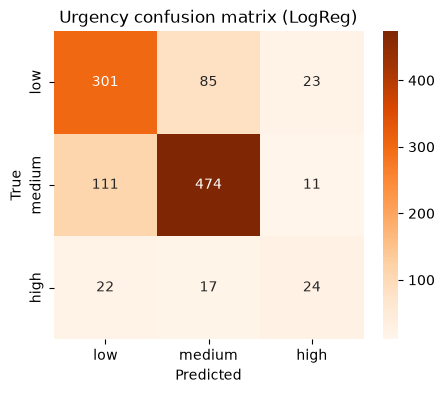

In [6]:
preds = urgency_models['logreg'].predict(X_test)
print(classification_report(test_df['urgency'], preds))

cm = confusion_matrix(test_df['urgency'], preds, labels=['low','medium','high'])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['low','medium','high'], yticklabels=['low','medium','high'], cmap='Oranges')
plt.title('Urgency confusion matrix (LogReg)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.show()


In [7]:
#saving combined results

In [8]:
all_results = {**category_results, **urgency_results}
res_df = pd.DataFrame(all_results).T
res_df.to_csv(MODEL_DIR / 'baseline_results.csv')
res_df

,accuracy,macro_f1
category_logreg,0.853933,0.653202
category_svm,0.878277,0.656563
urgency_logreg,0.748127,0.639895
urgency_svm,0.755618,0.605084


In [9]:
pd.set_option('display.max_colwidth', None)
test_df[fn_mask][['text', 'urgency']].sample(10, random_state=1)

NameError: name 'fn_mask' is not defined